# 02. Expériences : la segmentation par famille justifie-t-elle sa complexité ?

Ce notebook répond à deux questions, dans cet ordre : **la représentation B des absences apporte-t-elle quelque chose face à A ?** puis **un modèle par `ProductGroup` bat-il un modèle unique ?**

Comme le notebook 01, celui-ci reste au **niveau détaillé** : les appels `.fit()`, `.predict()`, les variables de score et les tableaux de comparaison sont visibles cellule par cellule. `src/experiences_02.py` regroupe les mêmes calculs en fonctions réutilisables (`baselines`, `fit_pair`, `architecture_gain`), et `tests/test_coherence_notebooks.py` vérifie que les deux produisent les mêmes prédictions et les mêmes scores.

Les blocs A et B sont volontairement écrits deux fois, à l'identique au suffixe près : une boucle serait plus courte, mais masquerait que les deux méthodes reçoivent exactement le même traitement. C'est un choix de lisibilité, pas un oubli de factorisation.

Prérequis : exécuter `01 - Preparation.ipynb` avec la même valeur de `FENETRE`. Les entraînements utilisent 500 itérations et prennent du temps ; la lecture du code ne les exige pas.

**Parcours :**

1. Chargement des données préparées et contrôles de séparation.
2. Références simples.
3. Configuration commune aux quatre candidats.
4. Modèle global, méthode A puis méthode B.
5. Modèles par famille, méthode A puis méthode B.
6. Comparaison, incertitude du gain, confirmation temporelle.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.base import clone
from catboost import CatBoostRegressor

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/preparation_03.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.fonctions_preparation_03 import split_X_y

FENETRE = "principal"
dossier_preparation = ROOT / "resultats/notebooks_03" / FENETRE
donnees = pd.read_pickle(dossier_preparation / "preparation.pkl.gz")
assert donnees["fenetre"] == FENETRE

trainA = donnees["trainA"]
valA = donnees["valA"]
trainB = donnees["trainB"]
valB = donnees["valB"]

## 1. Chargement et contrôles de séparation

Les données arrivent déjà préparées par 01. Les assertions qui suivent revérifient l'essentiel avant tout entraînement : aucune cible dans X, index disjoints entre apprentissage et validation, séparation chronologique stricte, et aucune vente de 2012. Ces contrôles sont bon marché et attrapent une erreur de manipulation bien avant qu'elle ne devienne un score trop beau.

In [2]:
X_trainA, y_trainA, X_valA, y_valA, X_trainB, y_trainB, X_valB, y_valB = split_X_y(trainA, valA, trainB, valB, "logSalePrice", ["saledate", "SalePrice"])

datesA = trainA["saledate"]
datesB = trainB["saledate"]
assert len(datesA) == len(X_trainA), "Désalignement datesA / X_trainA"
assert len(datesB) == len(X_trainB), "Désalignement datesB / X_trainB"
assert trainA.index.equals(trainB.index) and valA.index.equals(valB.index)
assert y_trainA.equals(y_trainB) and y_valA.equals(y_valB)
assert trainA.index.intersection(valA.index).empty
assert trainA["saledate"].max() < valA["saledate"].min()
assert valA["saledate"].max() < pd.Timestamp("2012-01-01")
assert X_trainA.columns.equals(X_valA.columns)
assert X_trainA.columns.equals(X_trainB.columns)
assert X_trainB.columns.equals(X_valB.columns)
for X in [X_trainA, X_valA, X_trainB, X_valB]:
    assert not {"SalePrice", "logSalePrice", "saledate"}.intersection(X.columns)
    assert not X.isna().any().any()

print(f"Fenêtre : {FENETRE}")
print(f"Apprentissage : {len(X_trainA)} ventes jusqu'au {datesA.max().date()}")
print(f"Validation : {len(X_valA)} ventes à partir du {valA['saledate'].min().date()}")

Fenêtre : principal
Apprentissage : 390213 ventes jusqu'au 2011-08-31
Validation : 10912 ventes à partir du 2011-09-01


## 2. Références simples

Avant tout modèle, il faut savoir ce que bat une règle triviale. Deux références : prédire toujours le log-prix moyen, puis le log-prix moyen de la famille. La seconde mesure ce que `ProductGroup` apporte à lui seul, ce qui sera utile pour juger ensuite si les modèles exploitent réellement le reste des caractéristiques.

Les moyennes sont calculées sur l'apprentissage uniquement.

Le score est `mean_squared_error(...) ** 0.5` appliqué à `log1p(SalePrice)`. Comme la cible est déjà en log, cette RMSE **est** le RMSLE sur les prix : c'est la même quantité que `rmsle_log` dans `src/experiences_02.py`, écrite ici avec la fonction scikit-learn pour laisser le calcul visible. Plus le score est faible, mieux c'est.

In [3]:
pred_moyenne = np.full(len(y_valA), y_trainA.mean())
moyenne_par_segment = y_trainA.groupby(X_trainA["ProductGroup"]).mean()
pred_moyenne_segment = X_valA["ProductGroup"].map(moyenne_par_segment).fillna(y_trainA.mean())

rmse_moyenne = mean_squared_error(y_valA, pred_moyenne) ** 0.5
rmse_moyenne_segment = mean_squared_error(y_valA, pred_moyenne_segment) ** 0.5
print(f"RMSLE moyenne globale : {rmse_moyenne:.5f}")
print(f"RMSLE moyenne par segment : {rmse_moyenne_segment:.5f}")

RMSLE moyenne globale : 0.72928
RMSLE moyenne par segment : 0.60851


## 3. Configuration commune aux quatre candidats

Les paramètres sont fixés **avant** la comparaison et identiques pour A, B, global et spécialistes : 500 itérations, profondeur 6, learning rate 0,1, graine 2012. La validation ne sert ni à chercher des paramètres, ni à arrêter l'entraînement : aucun `eval_set`, aucun early stopping. Sans cette discipline, le score de validation mesurerait en partie le réglage lui-même.

`clone` fournit un modèle neuf à chaque entraînement, sans état résiduel.

Le budget de 500 itérations s'applique **par modèle**. Les six spécialistes disposent donc collectivement de plus de capacité que le global : un gain de segmentation doit se lire en tenant compte de ce déséquilibre, et du coût de calcul supplémentaire qu'il implique.

In [4]:
model_base = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1,
                               loss_function="RMSE", random_seed=2012,
                               thread_count=8, verbose=100, allow_writing_files=False)
min_segment = 200
cat_features_A = X_trainA.select_dtypes(include=["object", "string"]).columns.tolist()
cat_features_B = X_trainB.select_dtypes(include=["object", "string"]).columns.tolist()

## 4. Modèle global, méthode A

Un seul modèle apprend sur toutes les familles, `ProductGroup` figurant parmi ses variables catégorielles. Il connaît donc déjà la famille de chaque machine : la segmentation ne lui ajoutera pas cette information, elle imposera un apprentissage séparé.

Le score d'apprentissage est affiché à côté de celui de validation pour situer l'écart entre les deux.

In [5]:
# ---- Modèle A ----
final_model_A = clone(model_base)
final_model_A.fit(X_trainA, y_trainA, cat_features=cat_features_A)

pred_val_A = final_model_A.predict(X_valA)
rmse_train_A = mean_squared_error(y_trainA, final_model_A.predict(X_trainA)) ** 0.5
rmse_val_A = mean_squared_error(y_valA, pred_val_A) ** 0.5

print(f"RMSLE Train A : {rmse_train_A:.5f}")
print(f"RMSLE Validation A : {rmse_val_A:.5f}")

0:	learn: 0.6487552	total: 1.62s	remaining: 13m 29s
100:	learn: 0.2529541	total: 3m 33s	remaining: 14m 4s
200:	learn: 0.2361007	total: 8m 15s	remaining: 12m 16s
300:	learn: 0.2281017	total: 10m 46s	remaining: 7m 7s
400:	learn: 0.2227735	total: 13m 34s	remaining: 3m 21s
499:	learn: 0.2191599	total: 16m 13s	remaining: 0us
RMSLE Train A : 0.21326
RMSLE Validation A : 0.23351


## 5. Modèle global, méthode B

Même modèle, mêmes paramètres, mêmes lignes : seule la représentation des absences catégorielles change. Tout écart de score avec le bloc précédent est donc imputable à cette seule différence.

In [6]:
# ---- Modèle B ----
final_model_B = clone(model_base)
final_model_B.fit(X_trainB, y_trainB, cat_features=cat_features_B)

pred_val_B = final_model_B.predict(X_valB)
rmse_train_B = mean_squared_error(y_trainB, final_model_B.predict(X_trainB)) ** 0.5
rmse_val_B = mean_squared_error(y_valB, pred_val_B) ** 0.5

print(f"RMSLE Train B : {rmse_train_B:.5f}")
print(f"RMSLE Validation B : {rmse_val_B:.5f}")

0:	learn: 0.6487552	total: 1.3s	remaining: 10m 47s
100:	learn: 0.2527525	total: 2m 24s	remaining: 9m 29s
200:	learn: 0.2358776	total: 4m 56s	remaining: 7m 20s
300:	learn: 0.2278147	total: 7m 29s	remaining: 4m 57s
400:	learn: 0.2224089	total: 9m 58s	remaining: 2m 27s
499:	learn: 0.2190138	total: 12m 30s	remaining: 0us
RMSLE Train B : 0.21301
RMSLE Validation B : 0.23258


## 6. Comparaison A / B sur les modèles globaux

Le tableau réunit les scores d'apprentissage et de validation des deux méthodes.

**Sur l'écart validation − apprentissage :** il cumule deux effets distincts et ne mesure pas uniquement le surapprentissage. La validation porte sur une période **postérieure** à l'apprentissage : une partie de l'écart vient du décalage temporel du marché, pas de la mémorisation. Un modèle parfaitement régularisé afficherait encore un écart si les prix ont bougé entre les deux périodes.

La décision A/B n'est pas prise ici : elle attend aussi les résultats de segmentation.

In [7]:
comparison = pd.DataFrame({
    "Méthode A": {
        "RMSLE Train": round(rmse_train_A, 5),
        "RMSLE Validation": round(rmse_val_A, 5),
        "Écart validation - apprentissage": round(rmse_val_A - rmse_train_A, 5),
    },
    "Méthode B": {
        "RMSLE Train": round(rmse_train_B, 5),
        "RMSLE Validation": round(rmse_val_B, 5),
        "Écart validation - apprentissage": round(rmse_val_B - rmse_train_B, 5),
    }
})
print(comparison)

                                  Méthode A  Méthode B
RMSLE Train                         0.21326    0.21301
RMSLE Validation                    0.23351    0.23258
Écart validation - apprentissage    0.02025    0.01957


## 7. Modèles par famille, méthode A

Un modèle est entraîné pour chaque `ProductGroup` comptant au moins 200 ventes d'apprentissage. `ProductGroup` est retiré de ses variables puisqu'il est constant à l'intérieur d'un segment.

Les prédictions partent de celles du modèle global ; seules celles des familles disposant d'un spécialiste sont remplacées. Une famille inconnue ou trop petite conserve donc la prédiction globale : **toutes les ventes de validation restent dans le score**, aucune ligne difficile n'est écartée. C'est la condition pour que la comparaison porte sur les deux architectures complètes, et pas sur un sous-ensemble favorable.

In [8]:
pred_val_segmente_A = pd.Series(pred_val_A, index=X_valA.index)
repli_A = pd.Series(True, index=X_valA.index)
modeles_segment_A = {}
variables_segment_A = X_trainA.columns.drop("ProductGroup").tolist()
cat_segment_A = [col for col in cat_features_A if col != "ProductGroup"]

for groupe in sorted(X_trainA["ProductGroup"].unique()):
    idx_train_segment = X_trainA.index[X_trainA["ProductGroup"] == groupe]
    idx_val_segment = X_valA.index[X_valA["ProductGroup"] == groupe]
    if len(idx_train_segment) < min_segment or len(idx_val_segment) == 0:
        continue

    print(f"Méthode A — segment {groupe} : {len(idx_train_segment)} ventes")
    model_segment = clone(model_base)
    model_segment.fit(X_trainA.loc[idx_train_segment, variables_segment_A],
                      y_trainA.loc[idx_train_segment], cat_features=cat_segment_A)
    pred_val_segmente_A.loc[idx_val_segment] = model_segment.predict(X_valA.loc[idx_val_segment, variables_segment_A])
    repli_A.loc[idx_val_segment] = False
    modeles_segment_A[groupe] = model_segment

rmse_val_segmente_A = mean_squared_error(y_valA, pred_val_segmente_A) ** 0.5
print(f"RMSLE Validation segmenté A : {rmse_val_segmente_A:.5f}")
print(f"Ventes avec repli global : {repli_A.sum()}")

Méthode A — segment BL : 77642 ventes
0:	learn: 0.3673723	total: 185ms	remaining: 1m 32s
100:	learn: 0.1622430	total: 18s	remaining: 1m 11s
200:	learn: 0.1525001	total: 33.2s	remaining: 49.4s
300:	learn: 0.1482600	total: 45.4s	remaining: 30s
400:	learn: 0.1452622	total: 56.8s	remaining: 14s
499:	learn: 0.1432418	total: 1m 7s	remaining: 0us
Méthode A — segment MG : 24841 ventes
0:	learn: 0.7015063	total: 104ms	remaining: 51.9s
100:	learn: 0.2061014	total: 11.5s	remaining: 45.3s
200:	learn: 0.1908359	total: 22.9s	remaining: 34.1s
300:	learn: 0.1838018	total: 34.5s	remaining: 22.8s
400:	learn: 0.1794293	total: 46s	remaining: 11.4s
499:	learn: 0.1751536	total: 57.5s	remaining: 0us
Méthode A — segment SSL : 41921 ventes
0:	learn: 0.3239700	total: 123ms	remaining: 1m 1s
100:	learn: 0.1887606	total: 12.5s	remaining: 49.4s
200:	learn: 0.1796694	total: 25.5s	remaining: 38s
300:	learn: 0.1753111	total: 38.4s	remaining: 25.4s
400:	learn: 0.1727245	total: 51s	remaining: 12.6s
499:	learn: 0.1704328

## 8. Modèles par famille, méthode B

Bloc identique au précédent, appliqué à la préparation B. Répéter le code plutôt que boucler rend visible que les deux méthodes reçoivent strictement le même traitement.

In [9]:
pred_val_segmente_B = pd.Series(pred_val_B, index=X_valB.index)
repli_B = pd.Series(True, index=X_valB.index)
modeles_segment_B = {}
variables_segment_B = X_trainB.columns.drop("ProductGroup").tolist()
cat_segment_B = [col for col in cat_features_B if col != "ProductGroup"]

for groupe in sorted(X_trainB["ProductGroup"].unique()):
    idx_train_segment = X_trainB.index[X_trainB["ProductGroup"] == groupe]
    idx_val_segment = X_valB.index[X_valB["ProductGroup"] == groupe]
    if len(idx_train_segment) < min_segment or len(idx_val_segment) == 0:
        continue

    print(f"Méthode B — segment {groupe} : {len(idx_train_segment)} ventes")
    model_segment = clone(model_base)
    model_segment.fit(X_trainB.loc[idx_train_segment, variables_segment_B],
                      y_trainB.loc[idx_train_segment], cat_features=cat_segment_B)
    pred_val_segmente_B.loc[idx_val_segment] = model_segment.predict(X_valB.loc[idx_val_segment, variables_segment_B])
    repli_B.loc[idx_val_segment] = False
    modeles_segment_B[groupe] = model_segment

rmse_val_segmente_B = mean_squared_error(y_valB, pred_val_segmente_B) ** 0.5
print(f"RMSLE Validation segmenté B : {rmse_val_segmente_B:.5f}")
print(f"Ventes avec repli global : {repli_B.sum()}")

Méthode B — segment BL : 77642 ventes
0:	learn: 0.3673723	total: 186ms	remaining: 1m 32s
100:	learn: 0.1622430	total: 17.3s	remaining: 1m 8s
200:	learn: 0.1525001	total: 28.4s	remaining: 42.2s
300:	learn: 0.1482600	total: 39.2s	remaining: 25.9s
400:	learn: 0.1452622	total: 50.2s	remaining: 12.4s
499:	learn: 0.1432418	total: 1m 1s	remaining: 0us
Méthode B — segment MG : 24841 ventes
0:	learn: 0.7015063	total: 66.3ms	remaining: 33.1s
100:	learn: 0.2061014	total: 10.9s	remaining: 43.3s
200:	learn: 0.1908359	total: 22.8s	remaining: 33.9s
300:	learn: 0.1838018	total: 34.6s	remaining: 22.8s
400:	learn: 0.1794293	total: 46.3s	remaining: 11.4s
499:	learn: 0.1751536	total: 58.1s	remaining: 0us
Méthode B — segment SSL : 41921 ventes
0:	learn: 0.3239700	total: 126ms	remaining: 1m 2s
100:	learn: 0.1887606	total: 12.9s	remaining: 51.1s
200:	learn: 0.1796694	total: 25.9s	remaining: 38.5s
300:	learn: 0.1753111	total: 38.7s	remaining: 25.6s
400:	learn: 0.1727245	total: 51.4s	remaining: 12.7s
499:	lear

## 9. Comparaison finale

Le score total est calculé sur toutes les ventes de validation ; ce n'est pas la moyenne non pondérée des scores par famille, qui donnerait le même poids à une famille de 648 ventes et à une de 3 164. Le détail par famille sert ensuite à voir si un gain agrégé est réparti ou concentré.

**Règle de décision, fixée avant de lire les scores :** on retient B si son meilleur candidat améliore le meilleur A d'au moins 0,002 RMSLE, sinon on garde A. Le seuil est fixé à l'avance pour ne pas être ajusté après coup en fonction des résultats.

In [10]:
comparison = pd.DataFrame({
    "Méthode A": {"RMSLE Global": rmse_val_A, "RMSLE Segmenté": rmse_val_segmente_A,
                  "Gain segmentation": rmse_val_A - rmse_val_segmente_A},
    "Méthode B": {"RMSLE Global": rmse_val_B, "RMSLE Segmenté": rmse_val_segmente_B,
                  "Gain segmentation": rmse_val_B - rmse_val_segmente_B}
})
print(comparison.round(5))

resultats_segments = []
for methode, X_val, y_val, pred_global, pred_segmente, repli in [
    ("A", X_valA, y_valA, pd.Series(pred_val_A, index=X_valA.index), pred_val_segmente_A, repli_A),
    ("B", X_valB, y_valB, pd.Series(pred_val_B, index=X_valB.index), pred_val_segmente_B, repli_B)
]:
    for groupe in sorted(X_val["ProductGroup"].unique()):
        mask = X_val["ProductGroup"] == groupe
        score_global = mean_squared_error(y_val.loc[mask], pred_global.loc[mask]) ** 0.5
        score_segmente = mean_squared_error(y_val.loc[mask], pred_segmente.loc[mask]) ** 0.5
        resultats_segments.append({"methode": methode, "segment": groupe, "n": int(mask.sum()),
                                   "global": score_global, "segmente": score_segmente,
                                   "gain": score_global - score_segmente, "replis": int(repli.loc[mask].sum())})
resultats_segments = pd.DataFrame(resultats_segments)
print(resultats_segments)

meilleur_A = min(rmse_val_A, rmse_val_segmente_A)
meilleur_B = min(rmse_val_B, rmse_val_segmente_B)
winner = "B" if meilleur_A - meilleur_B >= 0.002 else "A"
if FENETRE == "principal":
    print(f"Méthode retenue sur la fenêtre principale : {winner}")
else:
    print("Confirmation : la méthode reste celle choisie sur la fenêtre principale.")

                   Méthode A  Méthode B
RMSLE Global         0.23351    0.23258
RMSLE Segmenté       0.21740    0.21740
Gain segmentation    0.01611    0.01519
   methode segment     n    global  segmente      gain  replis
0        A      BL  1773  0.177801  0.170024  0.007776       0
1        A      MG   648  0.233100  0.205751  0.027349       0
2        A     SSL  1567  0.203020  0.178505  0.024515       0
3        A     TEX  3164  0.240799  0.226502  0.014297       0
4        A     TTT  1965  0.259021  0.243661  0.015360       0
5        A      WL  1795  0.262673  0.245408  0.017264       0
6        B      BL  1773  0.177780  0.170024  0.007756       0
7        B      MG   648  0.228734  0.205751  0.022982       0
8        B     SSL  1567  0.202938  0.178505  0.024433       0
9        B     TEX  3164  0.240629  0.226502  0.014127       0
10       B     TTT  1965  0.256976  0.243661  0.013315       0
11       B      WL  1795  0.261598  0.245408  0.016190       0
Méthode retenue sur l

### Le gain est-il réparti ou concentré ?

Un gain agrégé peut venir d'une seule famille. Le graphique montre l'écart de RMSLE famille par famille : une barre positive signifie que le spécialiste fait mieux que le global sur ces mêmes ventes.

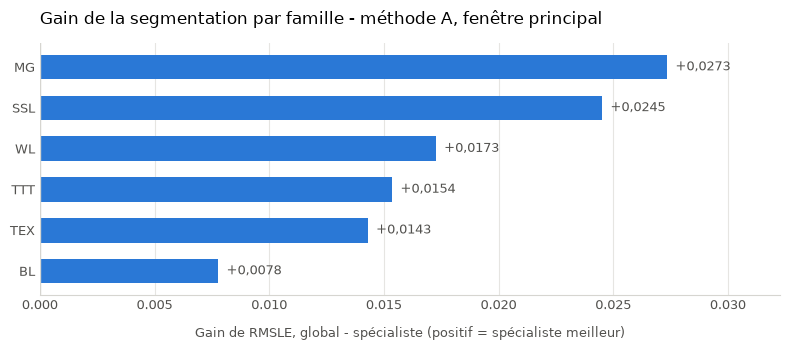

In [11]:
import matplotlib.pyplot as plt

COULEUR_GAIN = "#2a78d6"
COULEUR_PERTE = "#eb6834"
ENCRE_SECONDAIRE = "#52514e"
TRAIT = "#d6d5d0"

gains = resultats_segments.loc[resultats_segments["methode"] == "A"].sort_values("gain")
figure, axes = plt.subplots(figsize=(8, 3.6))
couleurs = [COULEUR_GAIN if g > 0 else COULEUR_PERTE for g in gains["gain"]]
axes.barh(gains["segment"], gains["gain"], color=couleurs, height=0.6)

for segment, gain in zip(gains["segment"], gains["gain"]):
    axes.annotate(f"{gain:+.4f}".replace(".", ","), (gain, segment),
                  textcoords="offset points", xytext=(6 if gain > 0 else -6, 0),
                  ha="left" if gain > 0 else "right", va="center",
                  fontsize=9, color=ENCRE_SECONDAIRE)

axes.axvline(0, color=TRAIT, linewidth=1)
axes.set_xlabel("Gain de RMSLE, global - spécialiste (positif = spécialiste meilleur)",
                fontsize=9, color=ENCRE_SECONDAIRE, labelpad=10)
axes.set_title(f"Gain de la segmentation par famille - méthode A, fenêtre {FENETRE}",
               fontsize=12, loc="left", pad=14)
axes.grid(axis="x", color=TRAIT, linewidth=0.8, alpha=0.6)
axes.set_axisbelow(True)
for bord in ["top", "right", "left"]:
    axes.spines[bord].set_visible(False)
axes.spines["bottom"].set_color(TRAIT)
axes.tick_params(length=0, colors=ENCRE_SECONDAIRE, labelsize=9)
axes.margins(x=0.18)
figure.tight_layout()
plt.show()

## 10. Incertitude du gain de segmentation

Un gain positif favorise la segmentation, mais un gain mesuré sur une seule période peut tenir à quelques semaines particulières. On rééchantillonne donc les semaines de validation, en gardant appariées les erreurs globale et segmentée des mêmes ventes : les deux architectures sont ainsi toujours jugées sur les mêmes semaines.

L'intervalle obtenu est **descriptif**. Il décrit la variabilité hebdomadaire des erreurs, pas celle des entraînements : les modèles ne sont pas réentraînés à chaque tirage. Il complète la confirmation sur une autre période, il ne la remplace pas.

In [12]:
intervalles = []
for methode, y_val, dates_val, pred_global, pred_segmente in [
    ("A", y_valA, valA["saledate"], pred_val_A, pred_val_segmente_A),
    ("B", y_valB, valB["saledate"], pred_val_B, pred_val_segmente_B)
]:
    erreurs = pd.DataFrame({"semaine": dates_val.dt.to_period("W"),
                            "global": (y_val - pred_global) ** 2,
                            "segmente": (y_val - pred_segmente) ** 2, "n": 1})
    erreurs_semaine = erreurs.groupby("semaine")[["global", "segmente", "n"]].sum().to_numpy()
    rng = np.random.default_rng(2012)
    tirages = rng.integers(0, len(erreurs_semaine), size=(1000, len(erreurs_semaine)))
    sommes = erreurs_semaine[tirages].sum(axis=1)
    gains = np.sqrt(sommes[:, 0] / sommes[:, 2]) - np.sqrt(sommes[:, 1] / sommes[:, 2])
    intervalles.append({"methode": methode, "borne_basse_95": np.quantile(gains, 0.025),
                        "borne_haute_95": np.quantile(gains, 0.975), "semaines": len(erreurs_semaine)})
intervalles = pd.DataFrame(intervalles).set_index("methode")
print(intervalles)

         borne_basse_95  borne_haute_95  semaines
methode                                          
A              0.012559        0.020032        18
B              0.012048        0.018641        18


## 11. Enregistrement et confirmation temporelle

Pour confirmer : réexécuter entièrement `01 - Preparation` avec `FENETRE = "confirmation"`, puis tout ce notebook avec la même valeur. Les fichiers de chaque fenêtre restent séparés.

La segmentation est retenue si, pour la méthode choisie sur la fenêtre principale : gain principal ≥ 0,003, borne basse de l'intervalle principal > 0, et gain positif sur la confirmation. Sinon on garde le global pour ce budget. Un test sur les ventes de 2012 mises de côté à la préparation (section 1) reste réservé à une évaluation ultérieure.

In [13]:
import json

scores = pd.DataFrame([
    {"methode": "A", "global": rmse_val_A, "segmente": rmse_val_segmente_A},
    {"methode": "B", "global": rmse_val_B, "segmente": rmse_val_segmente_B}
]).set_index("methode")
scores["gain"] = scores["global"] - scores["segmente"]
scores = scores.join(intervalles)
scores.to_csv(dossier_preparation / "scores.csv")
resultats_segments.to_csv(dossier_preparation / "segments.csv", index=False)
pd.DataFrame({"date": valA["saledate"], "y": y_valA, "global_A": pred_val_A,
              "segmente_A": pred_val_segmente_A, "global_B": pred_val_B,
              "segmente_B": pred_val_segmente_B}).to_csv(dossier_preparation / "predictions.csv", index=True)
contexte = {"params": model_base.get_params(), "min_segment": min_segment}
(dossier_preparation / "contexte.json").write_text(json.dumps(contexte, indent=2), encoding="utf-8")

dossier_principal = ROOT / "resultats/notebooks_03/principal"
dossier_confirmation = ROOT / "resultats/notebooks_03/confirmation"
if all((d / "scores.csv").exists() for d in [dossier_principal, dossier_confirmation]):
    principal = pd.read_csv(dossier_principal / "scores.csv", index_col="methode")
    confirmation = pd.read_csv(dossier_confirmation / "scores.csv", index_col="methode")
    winner = "B" if principal.loc["A", ["global", "segmente"]].min() - principal.loc["B", ["global", "segmente"]].min() >= 0.002 else "A"
    segmentation_confirmee = (principal.loc[winner, "gain"] >= 0.003
                              and principal.loc[winner, "borne_basse_95"] > 0
                              and confirmation.loc[winner, "gain"] > 0)
    architecture = "segmenté" if segmentation_confirmee else "global"
    print(f"Décision pour ce budget : méthode {winner}, modèle {architecture}")
else:
    print("Résultats enregistrés. Il manque une fenêtre : aucune décision d'architecture définitive.")

Résultats enregistrés. Il manque une fenêtre : aucune décision d'architecture définitive.
